In [1]:
import pypff
from glob import glob
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
%matplotlib widget

In [2]:
label_font = {'fontname':'sans-serif', 'size':'16', 'color':'black', 'weight':'normal',
          'verticalalignment':'bottom'} 
title_font = {'fontname':'sans-serif', 'size':'16', 'color':'black', 'weight':'bold'}


In [11]:
dirs = sorted(glob('obs_UCB*'))
#dir_index = -3
dir_index = -1
print(dirs[dir_index])
dfiles = sorted(glob('%s/*_ph256*'%dirs[dir_index]))
cmd = '%s/pypff_getmetadata.py %s -sf %s/m253.csv'%(dirs[dir_index], dfiles[0],dirs[dir_index])
os.system(cmd)
cmd = '%s/pypff_getmetadata.py %s -sf %s/m254.csv'%(dirs[dir_index], dfiles[1],dirs[dir_index])
os.system(cmd)

files = glob('%s/*.csv'%dirs[dir_index])

print(files)

obs_UCB_lab.start_2024-08-08T21:37:58Z.runtype_eng-test.pffd
ON FILE: ./obs_UCB_lab.start_2024-08-08T21:37:58Z.runtype_eng-test.pffd/start_2024-08-08T21:38:05Z.dp_ph256.bpp_2.module_253.seqno_0.pff
ON FILE: ./obs_UCB_lab.start_2024-08-08T21:37:58Z.runtype_eng-test.pffd/start_2024-08-08T21:38:05Z.dp_ph256.bpp_2.module_254.seqno_0.pff
['obs_UCB_lab.start_2024-08-08T21:37:58Z.runtype_eng-test.pffd/m254.csv', 'obs_UCB_lab.start_2024-08-08T21:37:58Z.runtype_eng-test.pffd/m253.csv']


In [12]:
df=np.zeros(2, dtype=object)

In [13]:
for i in range(len(files)):
    df[i] = pd.read_csv(files[i])
    df[i]['timestamp'] = np.array(len(df[i]), dtype=object)
    for j in range(len(df[i])):
        tstr = df[i]['Time (PT)'][j]
        nanosec = df[i]['Extra nanoseconds (ns)'][j]
        df[i].loc[j,'timestamp'] = datetime.strptime(tstr+'.'+str(int(nanosec/1000)), '%Y-%m-%d %H:%M:%S.%f')

Mean of Delta_t(ns):  -0.5043478260869565
STD of Delta_t(ns):  3.1440044060248997


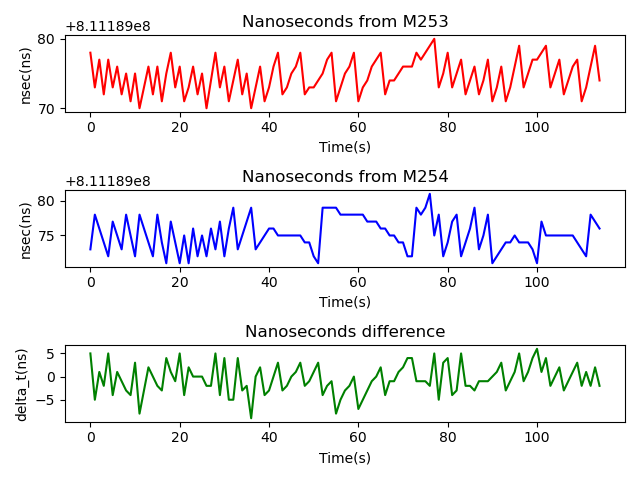

In [14]:
fig = plt.figure()

start_index = 0
# plot nanosec from m253
subplt0 = fig.add_subplot(311)
subplt0.plot(df[0]['Extra nanoseconds (ns)'][start_index:],c='red')
subplt0.set_xlabel('Time(s)')
subplt0.set_ylabel('nsec(ns)')
subplt0.set_title('Nanoseconds from M253')
# plot nanosec from m254
subplt1 = fig.add_subplot(312)
subplt1.plot(df[1]['Extra nanoseconds (ns)'][start_index:], c='blue')
subplt1.set_xlabel('Time(s)')
subplt1.set_ylabel('nsec(ns)')
subplt1.set_title('Nanoseconds from M254')
# plot nanosec difference
delta_t = df[0]['Extra nanoseconds (ns)'] - df[1]['Extra nanoseconds (ns)']
subplt2 = fig.add_subplot(313)
subplt2.plot(delta_t[start_index:],c='green')
subplt2.set_xlabel('Time(s)')
subplt2.set_ylabel('delta_t(ns)')
subplt2.set_title('Nanoseconds difference')
fig.tight_layout()
#fig.clear(all)

print('Mean of Delta_t(ns): ',np.mean(delta_t[start_index:]))
print('STD of Delta_t(ns): ', np.std(delta_t[start_index:]))

In [13]:
nsec_253 = df[0]['Extra nanoseconds (ns)']
nsec_254 = df[1]['Extra nanoseconds (ns)']
nsec_253_diff = nsec_253.diff()[1:]
nsec_254_diff = nsec_254.diff()[1:]

In [14]:
ts_253 = datetime.strptime(df[0]['Time (PT)'][0], '%Y-%m-%d %H:%M:%S')

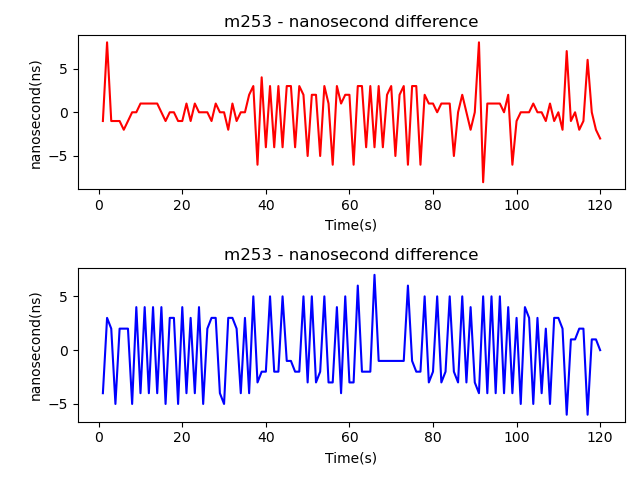

In [15]:
fig = plt.figure()
subplt0 = fig.add_subplot(211)
subplt0.plot(nsec_253_diff, c='red')
subplt0.set_xlabel('Time(s)')
subplt0.set_ylabel('nanosecond(ns)')
subplt0.set_title('m253 - nanosecond difference')

subplt1 = fig.add_subplot(212)
subplt1.plot(nsec_254_diff, c='blue')
subplt1.set_xlabel('Time(s)')
subplt1.set_ylabel('nanosecond(ns)')
subplt1.set_title('m253 - nanosecond difference')

fig.tight_layout()

Text(0, 0.5, 'Counts')

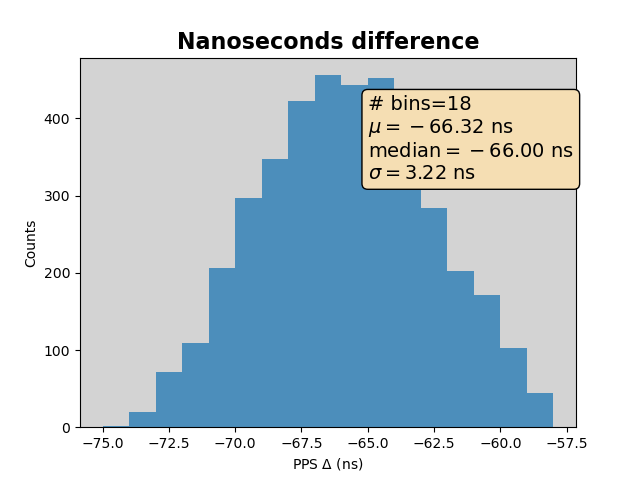

In [280]:
iqr = np.subtract(*np.percentile(delta_t, [75, 25]))
binWidth = 3*iqr/(len(delta_t)**(1/3.))
numBins = int((max(delta_t) - min(delta_t))/binWidth)

mu = delta_t.mean()
median = np.median(delta_t)
sigma = delta_t.std()

fig = plt.figure()

subfig = fig.add_subplot(111)
n, bins, patches = subfig.hist(delta_t,bins=numBins, alpha = 0.75)

#subfig.set_yscale('log')
subfig.set_facecolor('lightgrey')

textstr = '\n'.join((
    r'# bins=%.0f ' %(len(bins)),
    r'$\mu=%.2f$ ns' % (mu, ),
    r'$\mathrm{median}=%.2f$ ns' % (median, ),
    r'$\sigma=%.2f$ ns' % (sigma, )))

props = dict(boxstyle='round', facecolor='wheat', alpha=1)

# place a text box in upper left in axes coords
subfig.text(-65, 430, textstr, fontsize=14, verticalalignment='top', bbox=props)

subfig.set_title('Nanoseconds difference', **title_font)
subfig.set_xlabel('PPS $\Delta$ (ns)')
subfig.set_ylabel('Counts')

In [277]:
qErrfns = np.zeros(2, dtype=object)
qErrfns[0] = glob('%s/qErr/*USB0/*_MERGED*'%dirs[dir_index])[0]
qErrfns[1] = glob('%s/qErr/*USB1/*_MERGED*'%dirs[dir_index])[0]
print(qErrfns)

['obs_UCB_lab.start_2024-07-08T20:15:59Z.runtype_eng-test.pffd/qErr/start_2024-07-08T13:15:47.088459.device_ttyUSB0/data-type_MERGED.start_2024-07-08T13:15:47.088459'
 'obs_UCB_lab.start_2024-07-08T20:15:59Z.runtype_eng-test.pffd/qErr/start_2024-07-08T13:15:53.105972.device_ttyUSB1/data-type_MERGED.start_2024-07-08T13:15:53.105972']


In [218]:
qErrfps = np.zeros(2, dtype=object)
i = 0
for fn in qErrfns:
    qErrfps[i] = pd.read_csv(fn)
    i = i + 1

In [260]:
for fp in qErrfps:
    fp.loc['timestamp'] = np.array(len(fp), dtype=object)
    i = 0
    for tstr in fp['pkt_unix_timestamp_TIM-TP']: 
        fp.loc[i,'timestamp'] = datetime.strptime(tstr, '%Y-%m-%d %H:%M:%S.%f')
        i = i + 1

/tmp/ipykernel_40419/3955986854.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fp.loc['timestamp'][i] = datetime.strptime(tstr, '%Y-%m-%d %H:%M:%S.%f')
/tmp/ipykernel_40419/3955986854.py:5: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  fp.loc['timestamp'][i] = datetime.strptime(tstr, '%Y-%m-%d %H:%M:%S.%f')


IndexError: index 27 is out of bounds for axis 0 with size 27

In [262]:
qErrfps[0].loc[['pkt_unix_timestamp_TIM-TP']]

KeyError: "None of [Index(['pkt_unix_timestamp_TIM-TP'], dtype='object')] are in the [index]"

In [31]:
ls

m253.csv
obs_UCB_lab.start_2024-07-06T23:17:39Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-08T18:48:32Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-08T18:51:45Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-08T20:03:23Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-08T20:15:59Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-08T21:47:40Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-15T18:59:34Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-15T19:14:57Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-15T19:32:30Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-15T19:38:54Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-15T21:15:24Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-15T21:23:37Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-16T20:41:44Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-16T20:55:37Z.runtype_eng-test.pffd/
obs_UCB_lab.start_2024-07-16T21:03:52Z.runtype_eng-test.pffd/
pypff_getmetadata.py*
quabo_timing/
quabo-timing.ipynb
test.i

In [32]:
rm m253.csv